
## Linear Regression Model

Linear regression is a supervised machine learning algorithm used to model the relationship between a dependent variable (y) and one or more independent variables (X). The goal of the model is to predict the value of the target variable based on the input features.

Linear regression assumes that there is a linear relationship between the input variables and the output variable. This means that changes in the predictor variables (X) are associated with proportional changes in the response variable (y). The relationship between these variables is represented by a straight line that best fits the data.



## Import libraries

In [3]:
#let's import the necessary libraries to create our linear regression model and evaluate its performance.
import sklearn as sk
import pandas as pd
import numpy as np  

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [15]:
#now let's load our clean data frame to create our linear regression model.
df = pd.read_csv('/Users/ingxrodriguez/Phase1-Linear-Regression-Model/Phase1-Linear-Regression-Model/Data/Clean_qsar_fish_toxicity.csv')

df.head()

,CIC0,SM1_Dz(Z),GATS1i,MLOGP,LC50,NdsCH_1,NdsCH_2,NdsCH_3,NdsCH_4,NdssC_1,NdssC_2,NdssC_3,NdssC_4,NdssC_5,NdssC_6
0,3.260,0.829,1.676,1.453,3.770,False,False,False,False,True,False,False,False,False,False
1,2.189,0.580,0.863,1.348,3.115,False,False,False,False,False,False,False,False,False,False
2,2.125,0.638,0.831,1.348,3.531,False,False,False,False,False,False,False,False,False,False
3,3.027,0.331,1.472,1.807,3.510,True,False,False,False,False,False,False,False,False,False
4,2.094,0.827,0.860,1.886,5.390,False,False,False,False,False,False,False,False,False,False


## Separate features and target

Well to train our regression model, the dataset must be divided into features and target variable. 
X are our independent variables and Y represents the depent variable (Outcome) we want to predic. so, I exlude LC50 in AXIS from features and select LC50 as a Y our target variable 



In [16]:
#Lest's separate our features and target variable (lc50) 

X = df.drop('LC50', axis=1)
y = df['LC50']

## Train/Test split

To evaluate the performance of the regression model, the dataset is divided into two subsets: a training set and a testing set. The training set is used to train the model and allow it to learn the relationship between the features (X) and the target variable (y). The testing set is used to evaluate how well the model performs on unseen data. This process helps prevent overfitting and provides a more reliable estimate of the model's predictive performance. 

In [ ]:
#le's train our linear regression model using the train_test_split function to split our data into training and testing sets. 80/20 split is commonly used for training and testing machine learning models, where 80% of the data is used for training the model and 20% is reserved for testing its performance on unseen data.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
# Display train/test split information
print(f"Total samples: {len(X)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nFeatures shape (X_train): {X_train.shape}")
print(f"Target shape (y_train): {y_train.shape}")
print(f"\nFeatures shape (X_test): {X_test.shape}")
print(f"Target shape (y_test): {y_test.shape}")

Total samples: 907
Training set size: 725 (79.9%)
Testing set size: 182 (20.1%)

Features shape (X_train): (725, 14)
Target shape (y_train): (725,)

Features shape (X_test): (182, 14)
Target shape (y_test): (182,)


In [33]:
#les't create our linear regression model and fit it to our training data.
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Make predictions

In [38]:
#lLet’s see how the model performs on the test data.

y_predictions = model.predict(X_test)




# Evaluate the model

In [ ]:
# Now I want to see R² tells us how much variance in LC50 the model explains and MSE (Mean Squared Error) measures how far predictions are from actual values.

print("MSE:",mean_squared_error(y_test,y_predictions))
print("R2:",r2_score(y_test,y_predictions))

MSE: 1.0899045492548314
R2: 0.540897079295684


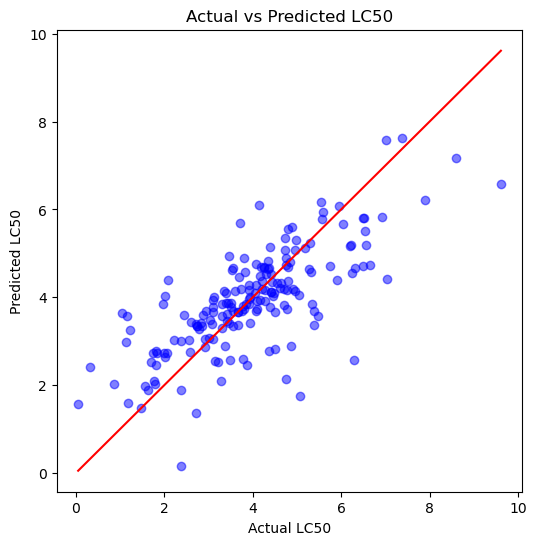

In [42]:
# Finally, let's visualize a plot of actual vs predicted LC50 values to see how well our model is performing. Ideally, the points should be close to the red line (y=x) if the predictions are accurate.

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_predictions, color='blue', alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual LC50")
plt.ylabel("Predicted LC50")
plt.title("Actual vs Predicted LC50")

plt.show()


## Summary: Training and Test Results

Splitting the data into a training set and a test set helps make sure the model learns from one part of the data and is tested on new data it has not seen before. This gives us a more honest idea of how well the model might work in the real world.

The mean squared error (MSE) is 1.09, which means that, on average, the model’s predictions are about one unit away from the real LC50 values. This suggests a moderate level of prediction error. The model cannot perfectly explain fish toxicity because LC50 depends on many chemical and biological factors that may not be included in this dataset.

R² score of about 0.54, which means that the model can explain about 54% of the variation in LC50 using the features in the dataset. This indicates that the model captures part of the relationship between the variables, but there are still other factors affecting toxicity that are not included in the model.

# Interpret coefficients

In [43]:
#Interpret coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.067499036925953
Coefficients: [ 0.41451519  1.28782177 -0.75427734  0.38951626  0.68859348  0.52310701
  0.47547924  0.93976148  0.00433779  0.27659974 -0.20036147  0.24066014
  1.19950453  0.54227564]


In [ ]:
#Lest's check this results in a more interpretable way by creating a table of features and their corresponding coefficients. This will help us understand which features have the most influence on the predicted LC50 values. 
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_table.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,SM1_Dz(Z),1.287822
12,NdssC_5,1.199505
7,NdsCH_4,0.939761
4,NdsCH_1,0.688593
13,NdssC_6,0.542276
5,NdsCH_2,0.523107
6,NdsCH_3,0.475479
0,CIC0,0.414515
3,MLOGP,0.389516
9,NdssC_2,0.276600


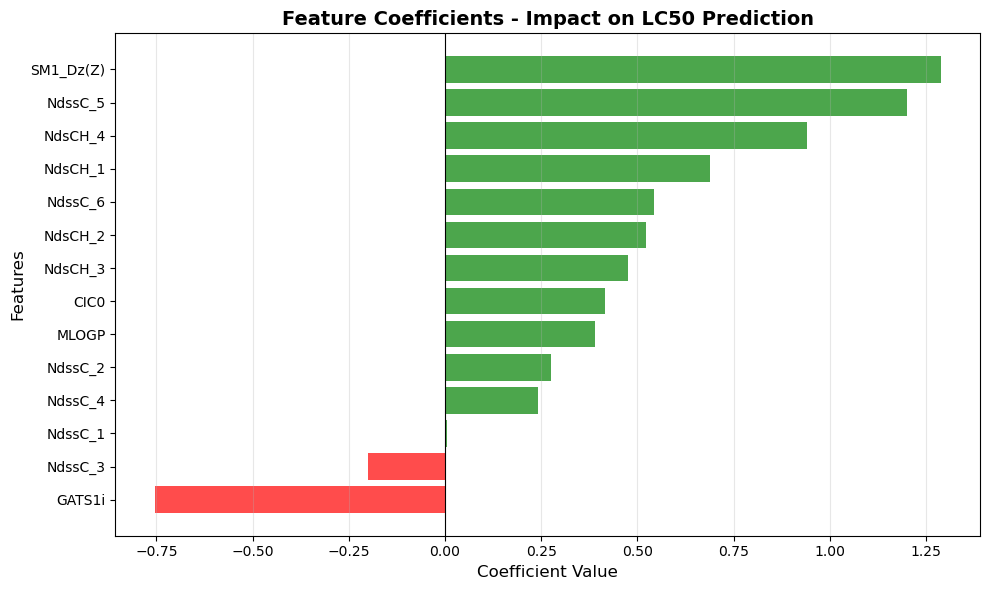

In [48]:
# Visualize the coefficients
sorted_coef = coef_table.sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in sorted_coef["Coefficient"]]
plt.barh(sorted_coef["Feature"], sorted_coef["Coefficient"], color=colors, alpha=0.7)

plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Feature Coefficients - Impact on LC50 Prediction", fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Coefficient Interpretation

The bar chart shows how each feature influences the prediction of LC50 in the linear regression model. Positive coefficients indicate that an increase in that feature tends to increase the predicted LC50 value, while negative coefficients indicate that the feature decreases the predicted LC50.

The results show that **SM1_Dz(Z)** has the strongest positive influence on LC50 predictions, followed by some categories of **NdssC** and **NdsCH** created during the one-hot encoding process. On the other hand, **GATS1i** has a negative coefficient, suggesting that higher values of this feature tend to reduce the predicted LC50. 

Overall, the chart helps visualize which molecular descriptors have the greatest impact on fish toxicity predictions in the model.

# Residual Plot

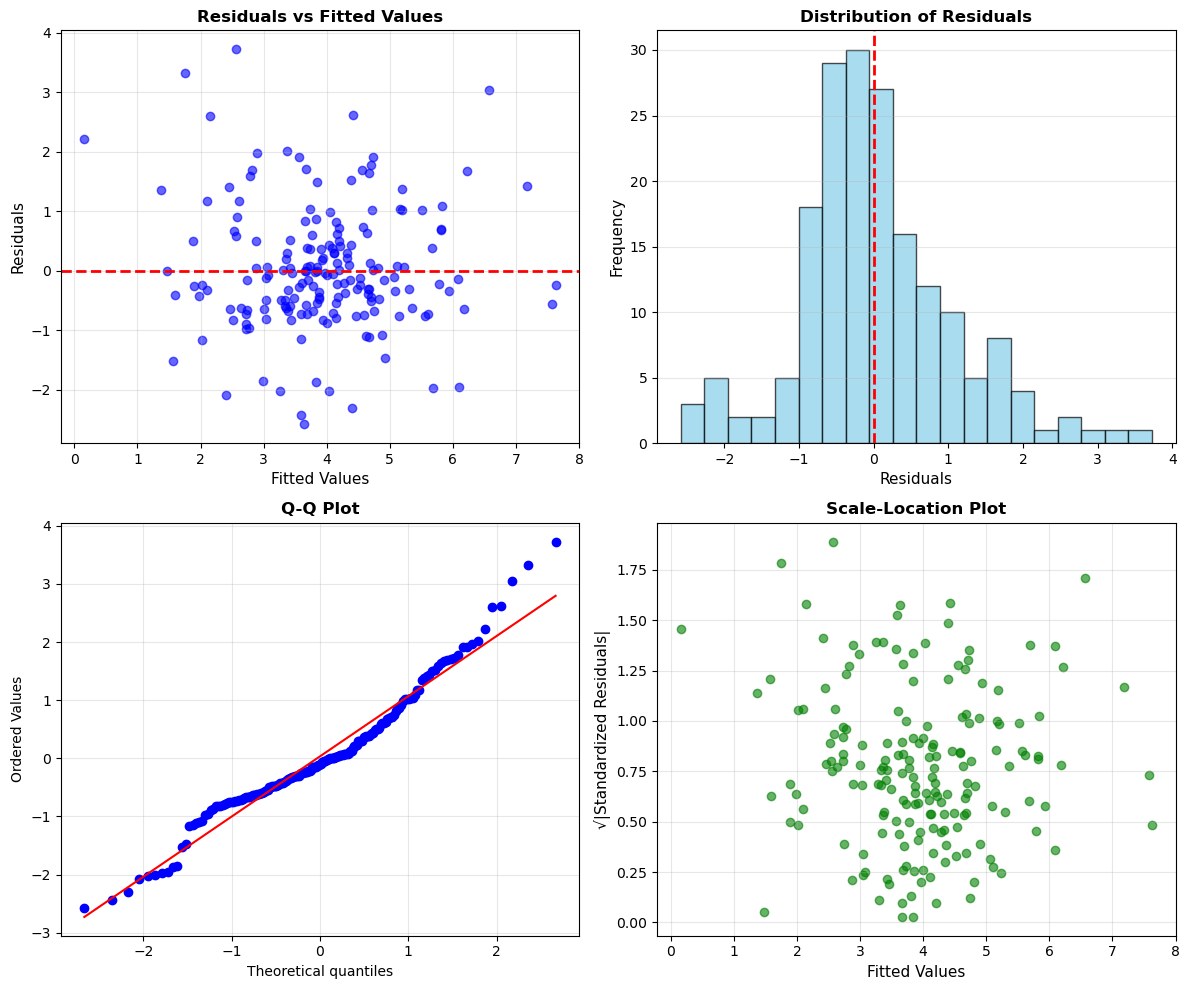

Residual Statistics:
Mean of residuals: 0.0324
Std dev of residuals: 1.0464
Min residual: -2.5821
Max residual: 3.7273


In [49]:
# Calculate residuals
residuals = y_test - y_predictions

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted values
axes[0, 0].scatter(y_predictions, residuals, alpha=0.6, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel("Fitted Values", fontsize=11)
axes[0, 0].set_ylabel("Residuals", fontsize=11)
axes[0, 0].set_title("Residuals vs Fitted Values", fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("Residuals", fontsize=11)
axes[0, 1].set_ylabel("Frequency", fontsize=11)
axes[0, 1].set_title("Distribution of Residuals", fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. Q-Q Plot (Normal Probability Plot)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot", fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Scale-Location Plot (Residuals vs Sqrt(|Residuals|))
standardized_residuals = residuals / np.std(residuals)
axes[1, 1].scatter(y_predictions, np.sqrt(np.abs(standardized_residuals)), alpha=0.6, color='green')
axes[1, 1].set_xlabel("Fitted Values", fontsize=11)
axes[1, 1].set_ylabel("√|Standardized Residuals|", fontsize=11)
axes[1, 1].set_title("Scale-Location Plot", fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("Residual Statistics:")
print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std dev of residuals: {residuals.std():.4f}")
print(f"Min residual: {residuals.min():.4f}")
print(f"Max residual: {residuals.max():.4f}")


## Summary: Residual Plot Analysis.

Residuals represent the difference between the observed LC50 values and the predicted values from the regression model. 

A good regression model should produce residuals that are randomly scattered around zero. This pattern suggests that the model captures the main relationship in the data without consistent over- or under-prediction.

Base on that we a mean of residuals close to zero which  is good for our model. The standard deviation of approximately 1.05 suggests that most prediction errors are around one LC50 unit. The minimum and maximum residuals show the largest prediction errors, ranging from about -2.58 to 3.73, indicating some variability in prediction accuracy.

